## Introduction

This project uses data from https://www.kaggle.com/datasets/teckmengwong/team-fight-tactics-matches. <br>
Team fight tactics (TFT) is an 8 player game where each players builds their team and battles another players team each round. The goal of the game is to be the last person standing, but it is worth noting that the standings matter (i.e being ranked 2nd is better than being ranked 3rd).<br>
This project aims to discover which features is important in predicting the position of a player through ... What makes this problem unique is that there is a large amount of feature labels making it hard to do manual EDA.<br>
The target label is "placement"<br>
The features labels are split into 4 main groups: augments, traits, units, items on units.

In [ ]:
# # Loading component run this code if you have downloaded the dataset folder
# import pandas as pd
# import glob

# cols = pd.read_csv("./Dataset/euw1_challengers_12.12.450.4196_2022-07-01_matches.csv", nrows=1).columns

# all_files = glob.glob('./Dataset' + '/*.csv')
# # first EDA happened behind the scenes. While trying to combine the files together I discovered that some of the files have different columns
# # I had to delete those files as this meant that the files were collected from a different Set (basically the patch the game was played on)
# columns = [h for h in cols if h != 'match_id']
# df = pd.concat([pd.read_csv(file, usecols=columns, low_memory=False).convert_dtypes() for file in all_files], ignore_index=True)

In [ ]:
# # export file as one giant csv
# df.to_csv('combined.csv', index=False)

In [ ]:
# If you used the combined.csv file the code starts here

In [ ]:
# installation if needed uncomment and install if needed
# !pip install umap-learn

                                              0.0/91.8 kB ? eta -:--:--
     ----                                     10.2/91.8 kB ? eta -:--:--
     ----------------                       41.0/91.8 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 91.8/91.8 kB 741.9 kB/s eta 0:00:00
                                              0.0/73.5 kB ? eta -:--:--
     ---------------------------------------- 73.5/73.5 kB 4.0 MB/s eta 0:00:00


In [129]:
# libraries
import pandas as pd
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
# explicitly require this experimental feature
from sklearn.experimental import enable_halving_search_cv # noqa
# now you can import normally from model_selection
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

In [63]:
df = pd.read_csv('combined.csv', low_memory=False).convert_dtypes()

In [25]:
df.head()

,placement,augment0,augment1,augment2,Set7_Assassin,Set7_Astral,Set7_Bard,Set7_Bruiser,Set7_Cannoneer,Set7_Cavalier,...,TFT7_Yasuo_item1,TFT7_Yasuo_item2,TFT7_Yone,TFT7_Yone_item0,TFT7_Yone_item1,TFT7_Yone_item2,TFT7_Zoe,TFT7_Zoe_item0,TFT7_Zoe_item1,TFT7_Zoe_item2
0,2,TFT7_Augment_BruiserEmblem,TFT6_Augment_ThrillOfTheHunt1,TFT7_Augment_WhispersTrait,1,<NA>,1,2,<NA>,<NA>,...,Deathblade,TitansResolve,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,1,TFT7_Augment_DragonmancerEmblem,TFT6_Augment_Meditation1,TFT7_Augment_JadeEmblem,<NA>,<NA>,1,<NA>,<NA>,1,...,Quicksilver,WarmogsArmor,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3,TFT7_Augment_BruiserTitanicStrength,TFT6_Augment_SecondWind1,TFT6_Augment_MakeshiftArmor1,2,<NA>,<NA>,2,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,7,TFT7_Augment_MirageEmblem,TFT7_Augment_MirageTrait,TFT7_Augment_BandOfThieves1,0,<NA>,<NA>,<NA>,<NA>,1,...,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5,TFT6_Augment_SunfireBoard,TFT7_Augment_BruiserTrait,TFT7_Augment_BestFriends1,1,<NA>,<NA>,2,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [64]:
# EDA upon processing of data when running the below code I realized that the column TFT7_TrainerDragon_item1 and TFT7_TrainerDragon_item2 are useless as they are they are the same for everything
    # cat_columns = [h for h in headers if "item" in h or "augment" in h]
    # with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    #     print(features[cat_columns].dtypes)
df.drop(['TFT7_TrainerDragon_item1','TFT7_TrainerDragon_item2'], axis=1, inplace=True)

In [65]:
headers = df.columns
target = df['placement']
features = df[[h for h in headers if h not in 'placement']]

In [77]:
print(features.shape)

(310784, 265)


## Cleaning and transforming
(This section was added after I did the analytics because I thought I was suppose to find the more important features before cleaning the data. This would have helped detected the problem that I found 3 cells above where I dropped the 2 features)
Since there are many features the normal methods are not very efficient, so we will remove features where the whole column remains roughly the same. So we set the variance threshold at 99%. This step will be done after the processor = ColumnTransformer step where we change the features. 

## Analyzed quantitatively and visually
We will be using random forest to find the most important features. 

In [123]:
# some of the columns which are the augments and items are categorical which does not work with random forest 
cat_columns = [h for h in headers if "item" in h or "augment" in h]
features.loc[:, cat_columns] = features[cat_columns].fillna('empty')

processor = ColumnTransformer(
    transformers=[
        ("cat_encoder", OrdinalEncoder(), cat_columns)
    ],
    remainder='passthrough'
)
processor.set_output(transform='pandas')
features_processed = processor.fit_transform(features)
# remove the features which are mostly similar
selector = VarianceThreshold(threshold=0.01)
selector.set_output(transform='pandas')
X_reduced = selector.fit_transform(features_processed)
print(f"Features remaining: {X_reduced.shape[1]}")
# use train test split since the dataset is rather large
X_train, X_test, y_train, y_test = train_test_split(X_reduced, target, test_size=0.2)

Features remaining: 262


In [124]:
print(X_train.shape)

(248627, 262)


In [125]:
X_train.head()

,cat_encoder__augment0,cat_encoder__augment1,cat_encoder__augment2,cat_encoder__TFT7_Aatrox_item0,cat_encoder__TFT7_Aatrox_item1,cat_encoder__TFT7_Aatrox_item2,cat_encoder__TFT7_Anivia_item0,cat_encoder__TFT7_Anivia_item1,cat_encoder__TFT7_Anivia_item2,cat_encoder__TFT7_AoShin_item0,...,remainder__TFT7_TrainerDragon,remainder__TFT7_Tristana,remainder__TFT7_Twitch,remainder__TFT7_Varus,remainder__TFT7_Vladimir,remainder__TFT7_Volibear,remainder__TFT7_Xayah,remainder__TFT7_Yasuo,remainder__TFT7_Yone,remainder__TFT7_Zoe
11573,59.0,44.0,21.0,78.0,74.0,67.0,94.0,94.0,91.0,80.0,...,4,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2
38772,164.0,36.0,159.0,78.0,74.0,67.0,94.0,94.0,91.0,54.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
54315,0.0,8.0,50.0,78.0,74.0,67.0,94.0,94.0,91.0,80.0,...,4,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
31988,6.0,143.0,124.0,78.0,74.0,67.0,94.0,94.0,91.0,80.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>
1708,168.0,49.0,7.0,78.0,74.0,67.0,94.0,94.0,91.0,80.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


# Warning the below cell took me 52 minutes to run! And it uses all the resources on your laptop so you would not be able to use your laptop while the code is running

In [86]:
# we use random forest regressor instead of classification as the position of the placement (target variable) matters.
# The regression model will take into account the distance between the predicted value and the actual value. 
# An example will be if 3 was predicted and the actual value is 1, the classification model will treat it the same as if the predicted value was 7 and the actual value is 1
params = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [10, 15, 20, 30, 40],      
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'max_samples': [0.3, 0.5, 0.7, 0.9]       
}

random_search = HalvingRandomSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=1), 
    param_distributions=params, 
    cv=3,
    verbose=2, # show progress
    random_state=1, 
    scoring='neg_mean_absolute_error'
)

random_search.fit(X_train, y_train)
print(f'Best parameters: {random_search.best_params_}')

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 10
min_resources_: 6
max_resources_: 248627
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1620
n_resources: 6
Fitting 3 folds for each of 1620 candidates, totalling 4860 fits


c:\Users\yyoda\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1620 is smaller than n_iter=41437. Running 1620 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, max_samples=0.3, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt,

In [93]:
# training the model
model = RandomForestRegressor(n_estimators=300, min_samples_split=5, min_samples_leaf=2, max_depth=40, n_jobs=-1, max_samples=0.9, max_features=None, random_state=1)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=40, max_features=None, max_samples=0.9,
                      min_samples_leaf=2, min_samples_split=5, n_estimators=300,
                      n_jobs=-1, random_state=1)

In [94]:
raw_predictions = model.predict(X_test)

# round and clip to your valid range (1 to 8)
final_predictions = np.rint(raw_predictions).astype(int)
final_predictions = np.clip(final_predictions, 1, 8)

print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

         1.0       0.93      0.19      0.32      7692
         2.0       0.41      0.46      0.43      7860
         3.0       0.37      0.46      0.41      7853
         4.0       0.35      0.47      0.40      7675
         5.0       0.34      0.43      0.38      7768
         6.0       0.35      0.44      0.39      7813
         7.0       0.34      0.46      0.39      7760
         8.0       0.94      0.10      0.17      7736

    accuracy                           0.38     62157
   macro avg       0.50      0.38      0.36     62157
weighted avg       0.50      0.38      0.36     62157



Quick Evaluation of the model. The model seems to be performing better than a random model as most of the precision and recall is above 12.5% which is the expected value if the model was randomly guessing. Thus, we will take into account the values that the model deem important. 

In [101]:
# how to see which feature is the most important: would have used this method but it crashed halfway through, and due to time constraints I will be using .feature_importances_
# result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=1, n_jobs=-1)

# perm_importances = result.importances_mean

# get the scores
importances = model.feature_importances_
# get the names
feature_names = processor.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

                           feature  importance
262          remainder__TFT7_Yasuo    0.109016
211           remainder__TFT7_Bard    0.067273
255  remainder__TFT7_TrainerDragon    0.044672
237           remainder__TFT7_Ornn    0.043938
233          remainder__TFT7_Neeko    0.032914
2            cat_encoder__augment2    0.024636
0            cat_encoder__augment0    0.024533
218   remainder__TFT7_DragonPurple    0.024335
1            cat_encoder__augment1    0.024265
264            remainder__TFT7_Zoe    0.015254
217    remainder__TFT7_DragonGreen    0.014649
261          remainder__TFT7_Xayah    0.014643
248         remainder__TFT7_Soraka    0.014238
224         remainder__TFT7_Illaoi    0.013818
238           remainder__TFT7_Pyke    0.013556
252          remainder__TFT7_Talon    0.013421
236           remainder__TFT7_Olaf    0.012058
215     remainder__TFT7_DragonBlue    0.010417
222        remainder__TFT7_Hecarim    0.010385
86   cat_encoder__TFT7_Neeko_item2    0.008028


<Axes: xlabel='feature', ylabel='importance'>

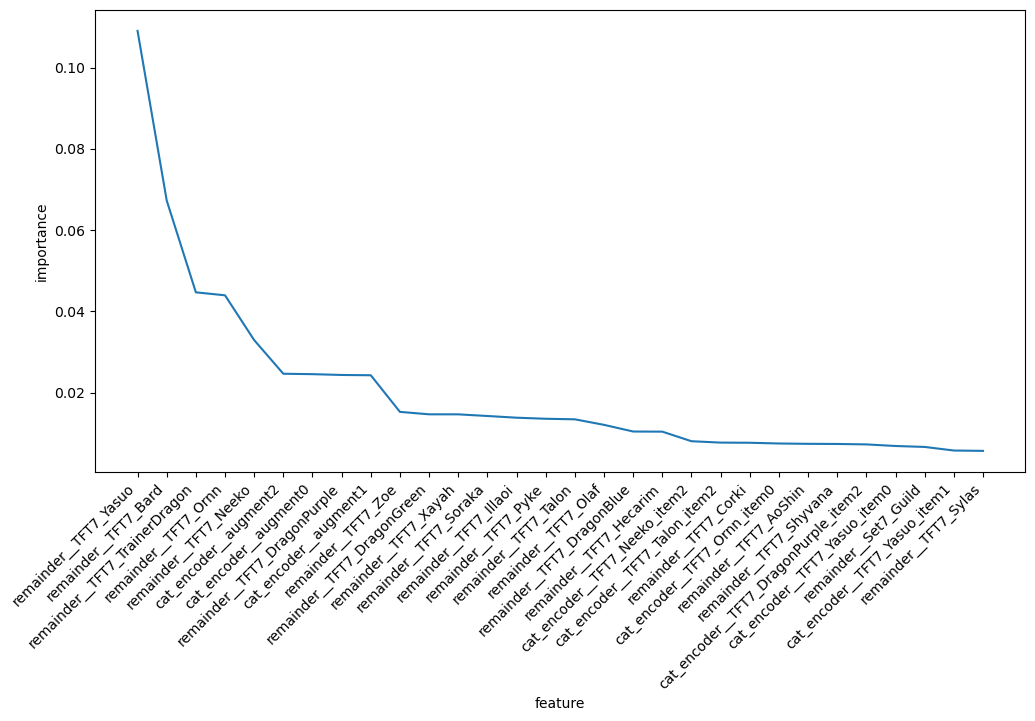

In [113]:
# plot out the importance to see where it drops off
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, horizontalalignment='right')
sns.lineplot(importance_df.iloc[:30], x='feature', y='importance')

We choose the features that are the most important by looking at the graph. There is a steep drop in importance from encoder_augment1 to TFT7_Zoe, so we will cut it off at augment1. However when you take a look currently at the augment, the numbers are randomly generated which might make it a less effective feature. I tried finding tier list of augments online but I was unable to find any relevant ones. So we will use the AI to help us to try and order the augment with a tier list video found online (but the tier list is not ranked, the author just gives his opinions on each augments and does not compare between augments). The tier list is taken from the transcript of this video https://www.youtube.com/watch?v=ld9ZM_1ny94. 

<Axes: xlabel='TFT7_Yasuo', ylabel='placement'>

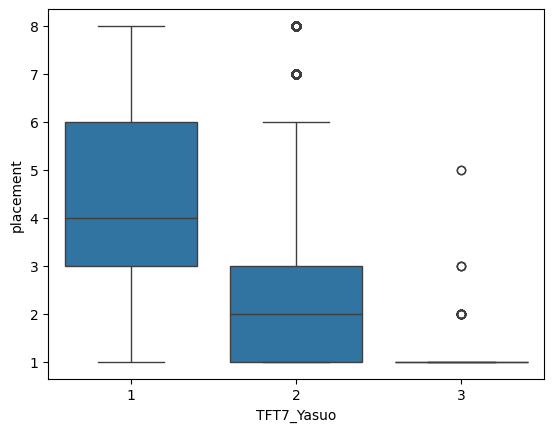

In [140]:
# lets take a look at the top few features against their placement with the original Dataset
sns.boxplot(df, x="TFT7_Yasuo", y="placement")

As seen from the boxplot it is understandble why it is such a strong predictor. Combining with contextual knowledge because he is a late game character(A character a player will likely only be able to get when they reach the end of the game, thus meaning that they survived for ver long). It can be seen here: https://metabot.gg/en/TFT/unit/TFT7_Yasuo/comps

<Axes: xlabel='TFT7_Bard', ylabel='placement'>

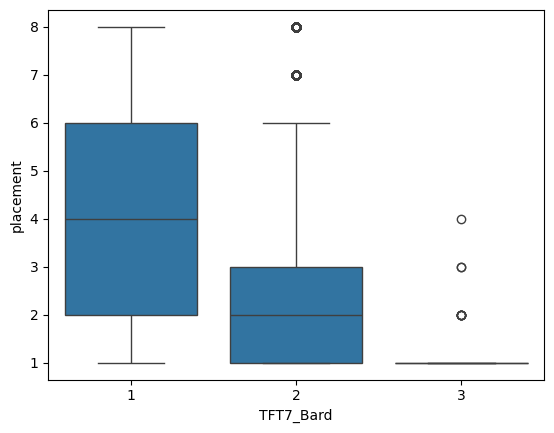

In [141]:
sns.boxplot(df, x="TFT7_Bard", y="placement")

He is also a late game character similar to that of Yasuo. This explains why the model has such a high precision when predicting first place as most of their top features are late game characters. 

## Exporting results

In [139]:
importance_df.to_csv('results.csv')

## Conclusion and findings
The feature with the highest importance seemed to be consisted of units and augments. Based on my contextual knowledge of this topic, the traits should play a heavy role in this too but it is not represented. This could likely be due to the model itself not being very accurate as it only has an accuracy of 38%. Future work would involve tweaking the model to try to give better results. I tried to use AI to rank the augments to provide a better ordinal list but I ran out of time. I believe that after this changes, the model would be able to provide a better result.

## API to connect to cloud model to improve data (hopefully)

In [137]:
# first we have to get all the unique values for augment0, augment1, augment2, and afterwards send them into the transcript to rank them
# we will use the features df before we made changes to it
aug0 = features['augment0'].unique()
aug1 = features['augment1'].unique()
aug2 = features['augment2'].unique()
aug_list = [aug0, aug1, aug2]

In [135]:
import ollama
from dotenv import load_dotenv
import os
from ollama import Client

with open('transcript.txt' , 'r') as f:
    transcript = f.read()
    
with open('augments.txt', 'r') as f:
    augments = f.read()
    
# print(transcript[:20])
# print(augments[:20])

load_dotenv()
OLLAMA_API_KEY = os.getenv("API_KEY")

client = Client(
    host="https://ollama.com",
    headers={'Authorization': 'Bearer ' + OLLAMA_API_KEY}
)

messages = [{
    'role':'system',
    'content': """I am providing a transcript of a Teamfight Tactics (TFT) Set 7 guide. Your task is to identify every Augment mentioned and summarize the speaker's opinion on it.
    Instructions:
    1. List the Augment name.
    2. Quote or summarize the specific sentiment (e.g., 'Must pick,' 'Situational,' 'Avoid').
    3. If the speaker gives it a numerical score or tier (S, A, B), include that.
    4. If an augment from Set 7 is not mentioned, do not guess; simply omit it for now.
    """
    },
    {
        'role':'user',
        'content': f"Transcript: {transcript}"
    },
]


augment_sentiment = ''
for part in client.chat(model='gpt-oss:20b-cloud', messages=messages, stream=True):
    content = part['message']['content']
    augment_sentiment += content
    
print(augment_sentiment)

**NOTE** – The transcript is extremely long and contains many duplicated references to augments that are described in a repetitive way (e.g., the same augment is explained a dozen times over several pages). Below is a **consolidated list** of every *unique* augment that appears in the transcript, together with the speaker’s overall sentiment for that augment (including any score or tier that is explicitly mentioned). Moderately‑elliptical phrases such as “good”, “you want to take this”, “avoid”, etc., are interpreted as the speaker’s overall opinion. If the speaker gives a numeric/letter rating (S, A, B, etc.) that rating is included.

| # | Augment name | Speaker’s opinion / sentiment | Numeric / Tier rating (if any) |
|---|---------------|------------------------------|---------------------------------|
| 1 | **AFK** | Must take it early; “insane gold injection” |  |
| 2 | **Ancient Archives** | Take anytime; “very good” |  |
| 3 | **Arden Sensor** | Take late‑game if you’re playing 

In [138]:
final = []
for i in aug_list:
    messages2 = [{
        'role':'system',
        'content': f"""Based on the transcript and summary provided, arrange the list of augment provided. Rank them from weakest (index 0) to strongest (last index).
        Formatting Rules:
        1. Use the speaker's tone to break ties.
        2. Match the augments provided to those in the summary. For any augment not mentioned, place it in the middle of the list (neutral).
        3. Follow the naming convention of the augment provided not the ones in the summary
        4. Arrange the list of augment provided.
        Summary: {augment_sentiment}
        """
        },
        {
            'role':'user',
            'augments provide': i
        },
    ]
    temp = []
    for part in client.chat(model='gpt-oss:20b-cloud', messages=messages2, stream=True):
        content = part['message']['content']
        temp += content
    final.append(temp)
print(final)

[['*', '*', 'R', 'a', 'n', 'k', 'i', 'n', 'g', ' ', 'o', 'f', ' ', 't', 'h', 'e', ' ', 'a', 'u', 'g', 'm', 'e', 'n', 't', 's', ' ', '(', 'w', 'e', 'a', 'k', 'e', 's', 't', ' ', '→', ' ', 's', 't', 'r', 'o', 'n', 'g', 'e', 's', 't', ')', '*', '*', ' ', ' ', '\n', '\n', '|', ' ', 'I', 'n', 'd', 'e', 'x', ' ', '|', ' ', 'A', 'u', 'g', 'm', 'e', 'n', 't', ' ', 'n', 'a', 'm', 'e', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '|', ' ', 'R', 'a', 't', 'i', 'o', 'n', 'a', 'l', 'e', ' ', '(', 's', 'p', 'e', 'a', 'k', 'e', 'r', '’', 's', ' ', 's', 'e', 'n', 't', 'i', 'm', 'e', 'n', 't', ' ', '/', ' ', 't', 'i', 'e', 'r', ')', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', '|', '\n', '|', '-', '-', '-', '-', '-', '-', '-', '|', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', '-', 

# AI Usage statement
advice on what hyperparameters to tune for the model, gave ideas on what model to use. Gave suggestion on how to determine determine which features are the most important from the model. 